In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
from scipy.stats import linregress 
plt.rcParams["figure.figsize"]=(12,6)

In [10]:
nav= pd.read_csv("../data/processed/clean_nav.csv")
perf= pd.read_csv("../data/processed/clean_performance.csv")
nav["date"]= pd.to_datetime(nav["date"])
print("nav shape:", nav.shape)
print("performance shape:",perf.shape)

nav shape: (46000, 3)
performance shape: (40, 20)


In [11]:
nav = nav.sort_values(
    by=["amfi_code", "date"]
)
nav["daily_return"]=(
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)
nav=nav.dropna()
nav.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


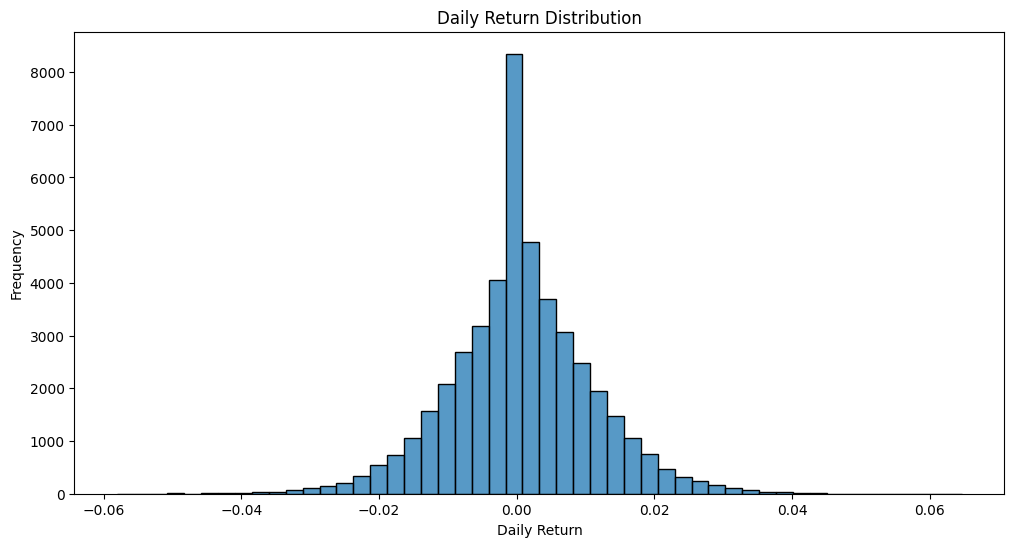

In [12]:
sns.histplot(
    nav["daily_return"],
    bins=50
)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [13]:
cagr_list = []
for fund in nav["amfi_code"].unique():
    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")
    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]
    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
    ) / 365
    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1
    cagr_list.append([fund, cagr])
cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr"]
)
cagr_df.head()

,amfi_code,cagr
0,100016,0.028788
1,100025,0.045425
2,100033,0.305184
3,101206,0.235044
4,101207,0.082066


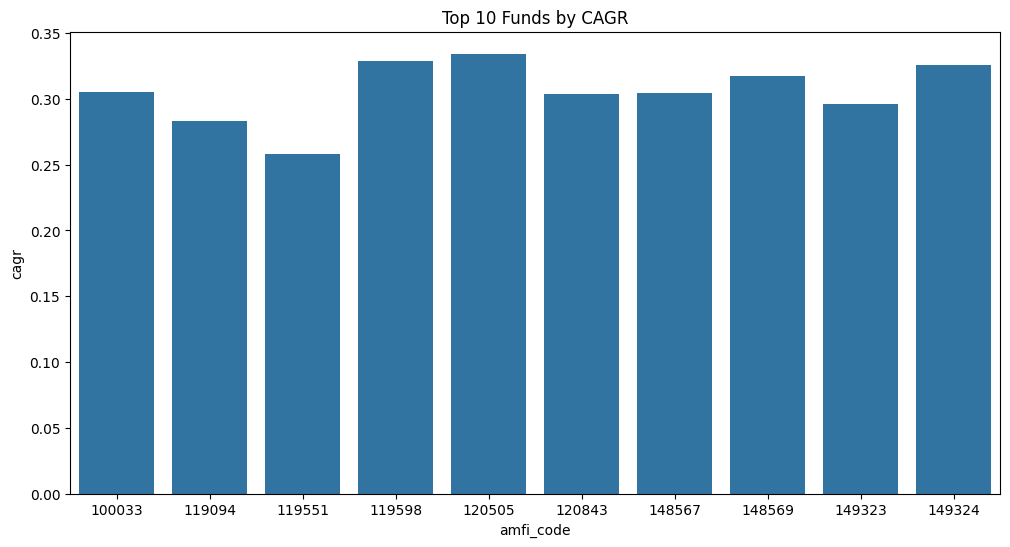

In [14]:
top_cagr = (
    cagr_df
    .sort_values(
        by="cagr",
        ascending=False
    )
    .head(10)
)
sns.barplot(
    data=top_cagr,
    x="amfi_code",
    y="cagr"
)
plt.title("Top 10 Funds by CAGR")
plt.show()

In [15]:
rf = 0.065
sharpe_list = []
for fund in nav["amfi_code"].unique():
    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]
    mean_return = returns.mean() * 252
    std_return = returns.std()
    sharpe = (
        (mean_return - rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_list.append([fund, sharpe])
sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


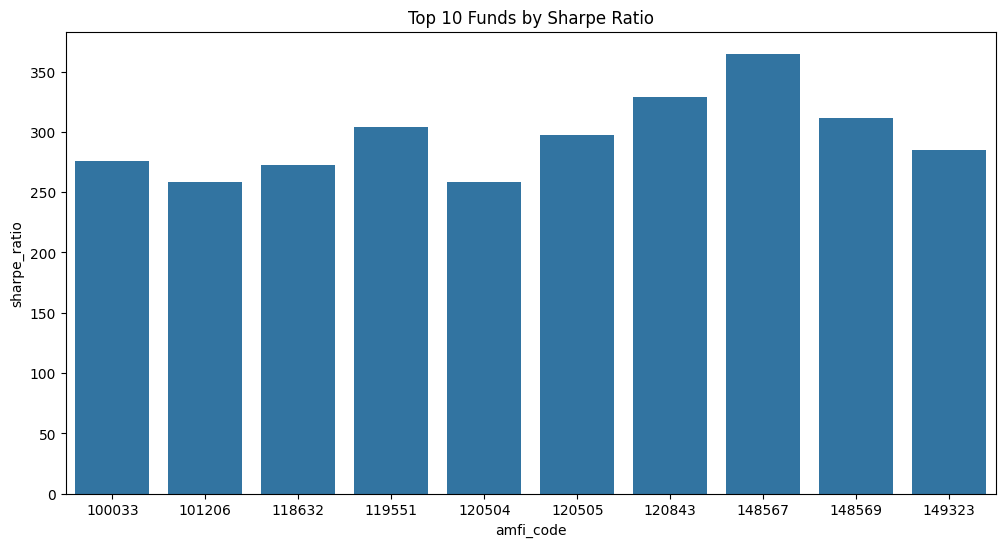

In [16]:
top_sharpe = (
    sharpe_df
    .sort_values(
        by="sharpe_ratio",
        ascending=False
    )
    .head(10)
)
sns.barplot(
    data=top_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)
plt.title("Top 10 Funds by Sharpe Ratio")
plt.show()

In [17]:
sortino_list = []
for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"]
    downside_returns = returns[
        returns < 0
    ]
    downside_std = downside_returns.std()
    mean_return = returns.mean() * 252
    sortino = (
        (mean_return - rf)
        / downside_std
    ) * np.sqrt(252)
    sortino_list.append([fund, sortino])
sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


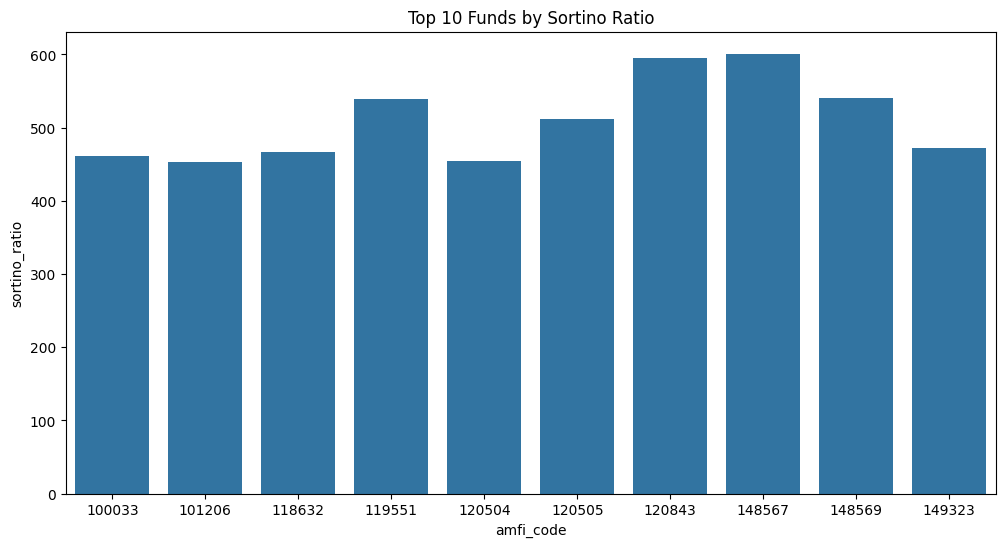

In [18]:
top_sortino = (
    sortino_df
    .sort_values(
        by="sortino_ratio",
        ascending=False
    )
    .head(10)
)
sns.barplot(
    data=top_sortino,
    x="amfi_code",
    y="sortino_ratio"
)
plt.title("Top 10 Funds by Sortino Ratio")
plt.show()

In [19]:
drawdown_data = [
    {
        "amfi_code": fund,
        "max_drawdown": (
            nav.loc[nav["amfi_code"] == fund, "nav"]
            .pipe(lambda s: (s / s.cummax()) - 1)
            .min()
        )
    }
    for fund in nav["amfi_code"].unique()
]
drawdown_df = pd.DataFrame(drawdown_data)
print(drawdown_df.head())

   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


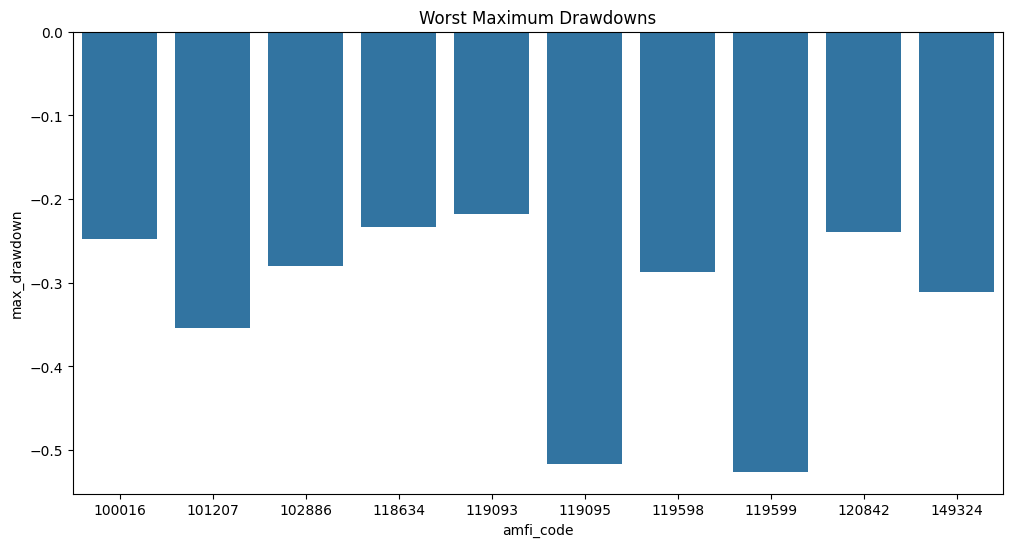

In [20]:
worst_dd = (
    drawdown_df
    .sort_values(
        by="max_drawdown"
    )
    .head(10)
)
sns.barplot(
    data=worst_dd,
    x="amfi_code",
    y="max_drawdown"
)
plt.title("Worst Maximum Drawdowns")
plt.show()

In [21]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)
scorecard["return_rank"]   = scorecard["cagr"].rank(ascending=False)    
scorecard["sharpe_rank"]   = scorecard["sharpe_ratio"].rank(ascending=False) 
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=True) 
scorecard["fund_score"] = (
    0.4 * scorecard["return_rank"] +
    0.4 * scorecard["sharpe_rank"] +
    0.2 * scorecard["drawdown_rank"]
)
scorecard = scorecard.sort_values(by="fund_score")
print(scorecard.head())

    amfi_code      cagr  sharpe_ratio  sortino_ratio  max_drawdown  \
25     120505  0.334332    297.385502     511.396941     -0.181885   
36     148569  0.316973    311.202366     541.022309     -0.163967   
39     149324  0.326028    239.348548     408.187880     -0.311719   
21     119598  0.328687    238.217681     422.179776     -0.287060   
2      100033  0.305184    275.612083     460.941758     -0.162172   

    return_rank  sharpe_rank  drawdown_rank  fund_score  
25          1.0          5.0           16.0         5.6  
36          4.0          3.0           20.0         6.8  
39          3.0         13.0            4.0         7.2  
21          2.0         14.0            5.0         7.4  
2           5.0          7.0           21.0         9.0  


In [22]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)
print("Fund Scorecard Exported")

Fund Scorecard Exported


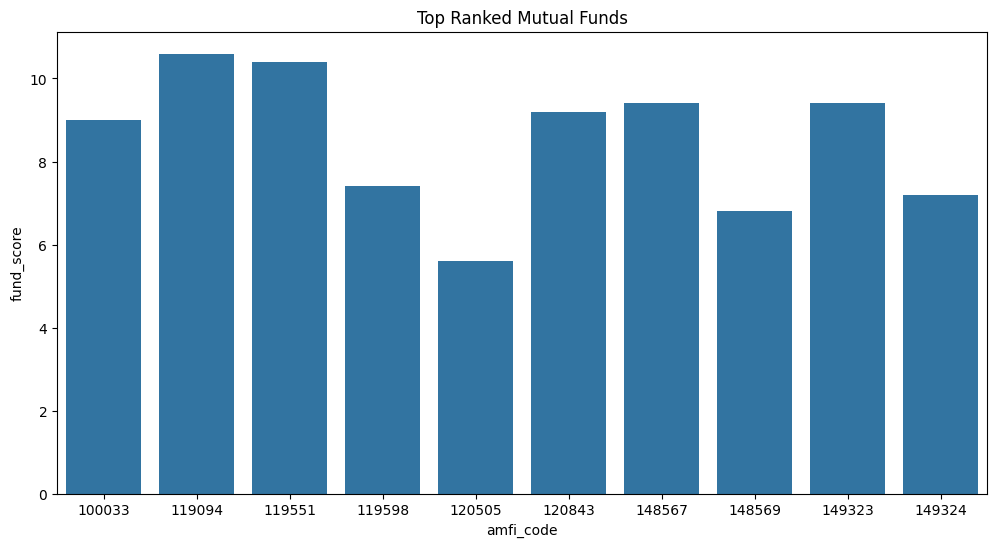

In [23]:
top_funds = scorecard.head(10)
sns.barplot(
    data=top_funds,
    x="amfi_code",
    y="fund_score"
)
plt.title("Top Ranked Mutual Funds")
plt.show()

In [24]:
benchmark = (
    nav.groupby("date")["daily_return"]
    .mean()
    .reset_index()
)
benchmark.columns = [
    "date",
    "benchmark_return"
]
alpha_beta_list = []
for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]
    merged = pd.merge(
        fund_df,
        benchmark,
        on="date"
    )
    slope, intercept, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    beta = slope
    alpha = intercept * 252
    alpha_beta_list.append([
        fund,
        alpha,
        beta
    ])
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [25]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)
print("Alpha Beta CSV Exported")

Alpha Beta CSV Exported


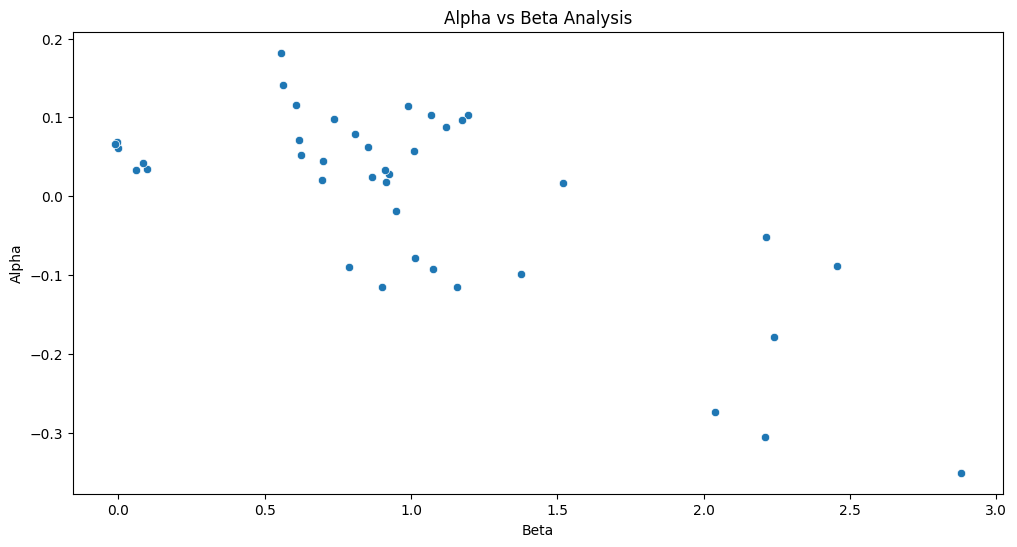

In [26]:
sns.scatterplot(
    data=alpha_beta_df,
    x="beta",
    y="alpha"
)
plt.title("Alpha vs Beta Analysis")
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.show()